In [3]:
import pandas as panda
import numpy as numpy
import seaborn as seaborn
import matplotlib.pyplot as matplot

In [5]:
#Cargar el Dataset "real_state_ecuador_dataset.csv"
archivo = panda.read_csv("real_state_ecuador_dataset.csv")

In [51]:
#Limpieza y normalización de "lugar"
archivo['Lugar'] = archivo['Lugar'].str.strip().str.title() #Quita los espacios extras y los pone modo título
archivo['Lugar'] = archivo['Lugar'].str.replace(r'\s+', ' ', regex=True) #Deja solo un espacio si hay más

In [52]:
#Validar la normalización contando cuantos datos existen 
print("Número total de lugar:", archivo['Lugar'].nunique())
#Mostrar los 10 lugares más frecuentes
print(archivo['Lugar'].value_counts().head(5))

Número total de lugar: 315
Lugar
Pichincha, Ponceano Alto, Quito, Ecuador                                19
Pichincha, El Bosque, Quito, Ecuador                                    12
Pichincha, Sangolqui, Sangolquí, Ecuador                                12
Pichincha, El Colibrí, Avenida General Rumiñahui, Sangolquí, Ecuador    10
Pichincha, Quito Tenis, Quito, Ecuador                                   9
Name: count, dtype: int64


In [53]:
#Ver que columnas tienen datos vacios 
archivo.isnull().sum()

Titulo                0
Precio                0
Provincia             0
Lugar                 0
Num. dormitorios    140
Num. banos           97
Area                 18
Num. garages        152
dtype: int64

In [16]:
#Manejar los valores faltantes 
archivo = archivo.dropna(subset=['Num. dormitorios']) #elimina las filas sin un dato de los dormitorios

archivo['Num. banos'] = archivo['Num. banos'].fillna(archivo['Num. banos'].median()) #rellena número de baños con la mediana
archivo['Area'] = archivo['Area'].fillna(archivo['Area'].median()) #rellena el área con la mediana

archivo['Num. garages'] = archivo['Num. garages'].fillna(0) #rellena el número de garajes con 0 porque no tienen

In [18]:
#Validar el manejo de los valores faltantes
print("Valores faltantes:\n", archivo.isnull().sum())

Valores faltantes:
 Titulo              0
Precio              0
Provincia           0
Lugar               0
Num. dormitorios    0
Num. banos          0
Area                0
Num. garages        0
dtype: int64


In [42]:
#Análisis descriptivo
#Total de propiedades, por Provincia, y por Lugar
print("Total de propiedades:\n", len(archivo))
print("Por Provincia:\n", archivo['Provincia'].value_counts())
print("Por Lugar:\n", archivo['Lugar'].value_counts().head(5))#total propiedades por lugar las primeras 5

Total de propiedades:
 358
Por Provincia:
 Provincia
Pichincha     313
Guayas         31
Manabí          6
Los Rios        3
Esmeraldas      2
Orellana        1
Imbabura        1
El Oro          1
Name: count, dtype: int64
Por Lugar:
 Lugar
Pichincha, Ponceano Alto, Quito, Ecuador      19
Pichincha, El Bosque, Quito, Ecuador          12
Pichincha, Quito Tenis, Quito, Ecuador         9
Pichincha, La Carolina, Quito, Ecuador         8
Pichincha, Gonzalez Suarez, Quito, Ecuador     7
Name: count, dtype: int64


In [39]:
#Cálculo de mediana y promedio de precio de alquiler (General y por Lugar)
print("Cálculo de la mediana y promedio\n\n")
print("Precio promedio general:", archivo['Precio'].mean())
print("Precio mediana general:", archivo['Precio'].median())
archivo.groupby('Lugar')['Precio'].agg(['mean','median']).head(5)

Cálculo de la mediana y promedio


Precio promedio general: 689.0893854748604
Precio mediana general: 500.0


,mean,median
Lugar,,
"El Oro, El Cambio, Machala, Ecuador",125.0,125.0
"Esmeraldas, Av. Club Del Pacífico, Tonsupa, Ecuador",508.0,508.0
"Esmeraldas, Casablanca, Same",140.0,140.0
"Guayas, 6º Pasaje 9 No Kennedy Guayaquil Guayaquil",400.0,400.0
"Guayas, 6º Pasaje 9 No, Guayaquil 090512, Ecuador",200.0,200.0


Análisis entre área y precio




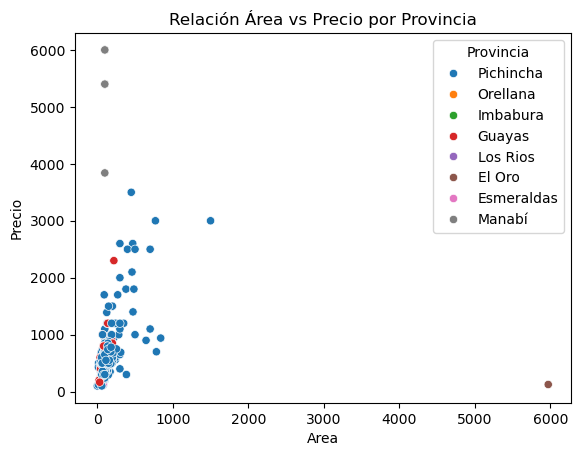

In [38]:
#Análisis entre área y precio
print("Análisis entre área y precio\n\n")
archivo_plot = archivo.dropna(subset=['Area','Precio']) # elimina nulos antes de graficar
seaborn.scatterplot(data=archivo_plot, x='Area', y='Precio', hue='Provincia')
matplot.title("Relación Área vs Precio por Provincia")
matplot.show()

In [43]:
#Análisis de Premium por Habitación Adicional: Diferencia del precio promedio entre propiedades de 1 habitación vs. 2 habitaciones; 2 habitaciones vs. 3, 3 vs. 4, etc.
#Tuve respuestas raras asi que convertir la columna a numérica
print("Análisis Premium\n\n")
archivo['Num. dormitorios'] = pandas.to_numeric(archivo['Num. dormitorios'], errors='coerce')
#Eliminar los números nulos o irreales
archivo = archivo.dropna(subset=['Num. dormitorios'])
archivo = archivo[archivo['Num. dormitorios'] > 0] 
#Aqui está el análisis
habitaciones_stats = archivo.groupby('Num. dormitorios')['Precio'].mean().sort_index()
print("Precio promedio por número de dormitorios:\n", habitaciones_stats)
premium = habitaciones_stats.diff()
print("\nPremium por habitación adicional:\n", premium)

Análisis Premium


Precio promedio por número de dormitorios:
 Num. dormitorios
1.0      851.153846
2.0      488.443299
3.0      588.111888
4.0     1175.000000
5.0     1300.000000
6.0     1500.000000
7.0     3000.000000
8.0      700.000000
10.0     125.000000
Name: Precio, dtype: float64

Premium por habitación adicional:
 Num. dormitorios
1.0             NaN
2.0     -362.710547
3.0       99.668589
4.0      586.888112
5.0      125.000000
6.0      200.000000
7.0     1500.000000
8.0    -2300.000000
10.0    -575.000000
Name: Precio, dtype: float64


In [44]:
#Otros Análisis
#Precio promedio por provincia
print("Precio promedio por provincia:\n", archivo.groupby('Provincia')['Precio'].mean().sort_values(ascending=False))
print("\n\n\n")
#Precio promedio por ciudad
archivo['Ciudad'] = archivo['Lugar'].apply(lambda x: x.split(',')[1].strip() if ',' in x else x) #Crear la columna ciudad 
print("Precio promedio por ciudad:\n", archivo.groupby('Ciudad')['Precio'].mean().sort_values(ascending=False).head(10))


Precio promedio por provincia:
 Provincia
Manabí        5340.000000
Pichincha      620.370607
Guayas         592.741935
Imbabura       480.000000
Esmeraldas     324.000000
Los Rios       233.333333
Orellana       150.000000
El Oro         125.000000
Name: Precio, dtype: float64




Precio promedio por ciudad:
 Ciudad
Puerto Cayo Playa                                5700.0
Puerto Cayo                                      4620.0
Plaza Del Rancho                                 3500.0
Avenida General Enriquez & Isla San Cristobal    3000.0
Santa Inés                                       2600.0
Pusuqui                                          2500.0
Avenue 12 De Octubre                             2500.0
Isla Mocoli                                      2300.0
Sector Plataforma Financiera Norte               2100.0
Luxemburgo                                       2000.0
Name: Precio, dtype: float64


Q1: 380.0
Q3: 680.0




TipoPrecio
Medio        184
Lujo          89
Económico     85
Name: count, dtype: int64


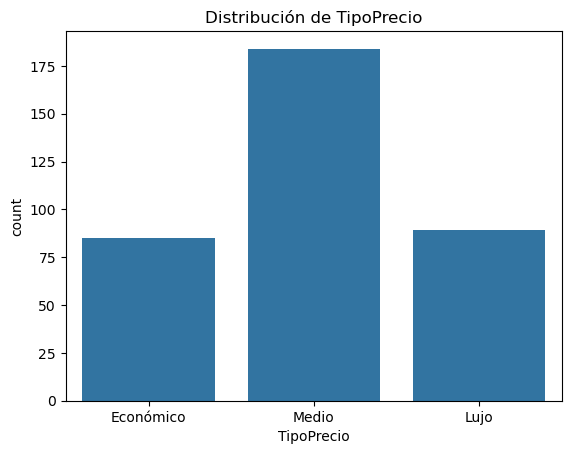

In [49]:
#Crear una nueva columna: Tipo de Precio por Lugar
#    Si precio < Q1 (Cuartil 1) -> "Económico"
#    Si precio > Q3 (Cuartil 3) -> "Lujo"
#    Resto -> "Medio"
Q1 = archivo['Precio'].quantile(0.25)  # Cuartil 1
Q3 = archivo['Precio'].quantile(0.75)  # Cuartil 3
print("Q1:", Q1)
print("Q3:", Q3)
print ("\n\n\n")
#Creación de la columna "TipoPrecio"
def clasificar_precio(precio):
    if precio < Q1:
        return "Económico"
    elif precio > Q3:
        return "Lujo"
    else:
        return "Medio"

archivo['TipoPrecio'] = archivo['Precio'].apply(clasificar_precio)
#Validación
conteo = archivo['TipoPrecio'].value_counts()
print(conteo)
seaborn.countplot(x='TipoPrecio', data=archivo, order=['Económico','Medio','Lujo'])
matplot.title("Distribución de TipoPrecio")
matplot.show()